# Sprint Notebook — Final 2-3 Day Push

Baseline: **v7 Platform 0.5636**, OOF 0.6429, M1-5 OOF 0.6515  
Sections: A · B · C · D · E · F · G · H

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import os

SEED       = 42
DATA_DIR   = '../data/'
MODEL_DIR  = '../models/'
SUBMIT_DIR = '../submissions/'

np.random.seed(SEED)
print('Imports OK')

Imports OK


In [3]:
# Load train and test data (needed for month_of_year mask and y)
print('Loading data...')
train_df = pd.read_parquet(f'{DATA_DIR}train_features_tier2.parquet')
test_df  = pd.read_parquet(f'{DATA_DIR}test_features_tier2.parquet')
y = train_df['invalid_ratio'].values
print(f'  Train: {train_df.shape}  Test: {test_df.shape}')
print(f'  Train months: {sorted(train_df["month_of_year"].unique())}')
print(f'  Test  months: {sorted(test_df["month_of_year"].unique())}')

Loading data...
  Train: (6076546, 31)  Test: (2028750, 30)
  Train months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  Test  months: [1, 2, 3, 4, 5]


---
## Section A — M1-5 Weight Optimization + Fine-Grained Search

**Rationale**: v7 weights (LGB=0.35, XGB=0.65) were optimised on full 12-month OOF
with step=0.05. The test set is M1-5 only. Re-searching on the M1-5 OOF subset
with finer step=0.01 may find weights that better match the test distribution.

Note: v8a OOF ≡ v7 OOF (step11_gpu.py trains identically to v7; only test-time TE
differs). We use v8a OOF files as the v7 OOF proxy when v7 files are absent.

In [4]:
# ── Load OOF predictions (prefer v7; fall back to v8a which is identical) ────
def load_oof(model, version_primary='v7', version_fallback='v8a'):
    primary  = f'{MODEL_DIR}{model}_oof_{version_primary}.npy'
    fallback = f'{MODEL_DIR}{model}_oof_{version_fallback}.npy'
    if os.path.exists(primary):
        arr = np.load(primary)
        print(f'  Loaded {primary}')
        return arr, version_primary
    elif os.path.exists(fallback):
        arr = np.load(fallback)
        print(f'  Loaded {fallback}  [proxy for {version_primary} — OOF is identical]')
        return arr, version_fallback
    else:
        raise FileNotFoundError(f'Neither {primary} nor {fallback} found.')

print('Loading OOF predictions...')
lgb_oof, lgb_ver = load_oof('lgb')
xgb_oof, xgb_ver = load_oof('xgb')

# CB oof v4 (optional — v7 ensemble gave it weight=0)
cb_oof_path = f'{MODEL_DIR}cb_oof_v4.npy'
cb_oof = np.load(cb_oof_path) if os.path.exists(cb_oof_path) else None
print(f'  CB v4 OOF: {"loaded" if cb_oof is not None else "not found (skip)"}')

lgb_rho = spearmanr(y, lgb_oof)[0]
xgb_rho = spearmanr(y, xgb_oof)[0]
print(f'\nFull OOF Spearman:')
print(f'  LGB ({lgb_ver}): {lgb_rho:.4f}  (expected ~0.6336)')
print(f'  XGB ({xgb_ver}): {xgb_rho:.4f}  (expected ~0.6403)')

Loading OOF predictions...
  Loaded ../models/lgb_oof_v8a.npy  [proxy for v7 — OOF is identical]
  Loaded ../models/xgb_oof_v8a.npy  [proxy for v7 — OOF is identical]
  CB v4 OOF: not found (skip)

Full OOF Spearman:
  LGB (v8a): 0.6336  (expected ~0.6336)
  XGB (v8a): 0.6403  (expected ~0.6403)


In [5]:
# ── M1-5 mask ─────────────────────────────────────────────────────────────────
m15_mask = train_df['month_of_year'].isin([1, 2, 3, 4, 5]).values
print(f'M1-5 train rows: {m15_mask.sum():,} / {len(train_df):,}')

y_m15      = y[m15_mask]
lgb_oof_m15 = lgb_oof[m15_mask]
xgb_oof_m15 = xgb_oof[m15_mask]
cb_oof_m15  = cb_oof[m15_mask] if cb_oof is not None else None

lgb_rho_m15 = spearmanr(y_m15, lgb_oof_m15)[0]
xgb_rho_m15 = spearmanr(y_m15, xgb_oof_m15)[0]
print(f'\nM1-5 OOF Spearman:')
print(f'  LGB: {lgb_rho_m15:.4f}')
print(f'  XGB: {xgb_rho_m15:.4f}')

M1-5 train rows: 2,470,429 / 6,076,546

M1-5 OOF Spearman:
  LGB: 0.6428
  XGB: 0.6482


In [6]:
# ── Fine-grained weight search (step=0.01) on M1-5 OOF ───────────────────────
from itertools import product

weights = np.arange(0, 1.01, 0.01)

best_rho_m15  = -1
best_w_m15    = None

# Search over LGB weight; XGB = 1 - lgb_w (CB=0 as in v7)
results_m15 = []
for lgb_w in weights:
    xgb_w = 1.0 - lgb_w
    pred = lgb_w * lgb_oof_m15 + xgb_w * xgb_oof_m15
    rho  = spearmanr(y_m15, pred)[0]
    results_m15.append((lgb_w, xgb_w, rho))
    if rho > best_rho_m15:
        best_rho_m15 = rho
        best_w_m15   = (lgb_w, xgb_w)

print(f'M1-5 weight search (step=0.01, CB=0) complete.')
print(f'  Best M1-5 weights : LGB={best_w_m15[0]:.2f}, XGB={best_w_m15[1]:.2f}')
print(f'  Best M1-5 OOF Rho : {best_rho_m15:.4f}')
print(f'\n  v7 weights        : LGB=0.35, XGB=0.65')
print(f'  v7 M1-5 OOF (ref) : 0.6515')

# Compare v7 weights on M1-5
pred_v7_m15 = 0.35 * lgb_oof_m15 + 0.65 * xgb_oof_m15
rho_v7_m15  = spearmanr(y_m15, pred_v7_m15)[0]
print(f'  v7 weights applied to M1-5 OOF: {rho_v7_m15:.4f}')
print(f'  Delta (new - v7): {best_rho_m15 - rho_v7_m15:+.4f}')

M1-5 weight search (step=0.01, CB=0) complete.
  Best M1-5 weights : LGB=0.39, XGB=0.61
  Best M1-5 OOF Rho : 0.6515

  v7 weights        : LGB=0.35, XGB=0.65
  v7 M1-5 OOF (ref) : 0.6515
  v7 weights applied to M1-5 OOF: 0.6515
  Delta (new - v7): +0.0000


In [7]:
# ── Also run fine-grained search on FULL OOF for comparison ──────────────────
best_rho_full = -1
best_w_full   = None
results_full  = []
for lgb_w in weights:
    xgb_w = 1.0 - lgb_w
    pred  = lgb_w * lgb_oof + xgb_w * xgb_oof
    rho   = spearmanr(y, pred)[0]
    results_full.append((lgb_w, xgb_w, rho))
    if rho > best_rho_full:
        best_rho_full = rho
        best_w_full   = (lgb_w, xgb_w)

print(f'Full OOF weight search (step=0.01, CB=0) complete.')
print(f'  Best full weights : LGB={best_w_full[0]:.2f}, XGB={best_w_full[1]:.2f}')
print(f'  Best full OOF Rho : {best_rho_full:.4f}')

print(f'\n=== Summary ===')
print(f'  Full-OOF optimal : LGB={best_w_full[0]:.2f}  XGB={best_w_full[1]:.2f}  Rho={best_rho_full:.4f}')
print(f'  M1-5-OOF optimal : LGB={best_w_m15[0]:.2f}  XGB={best_w_m15[1]:.2f}  Rho={best_rho_m15:.4f}')
print(f'  v7 weights       : LGB=0.35   XGB=0.65')

Full OOF weight search (step=0.01, CB=0) complete.
  Best full weights : LGB=0.36, XGB=0.64
  Best full OOF Rho : 0.6429

=== Summary ===
  Full-OOF optimal : LGB=0.36  XGB=0.64  Rho=0.6429
  M1-5-OOF optimal : LGB=0.39  XGB=0.61  Rho=0.6515
  v7 weights       : LGB=0.35   XGB=0.65


In [8]:
# ── Optional: 3-model search including CB (if available) ─────────────────────
if cb_oof is not None:
    best_rho_3m = -1
    best_w_3m   = None
    step = 0.05  # coarser for 3-model to keep it fast
    ws   = np.arange(0, 1.01, step)
    for lgb_w in ws:
        for xgb_w in ws:
            cb_w = round(1.0 - lgb_w - xgb_w, 4)
            if cb_w < 0 or cb_w > 1:
                continue
            pred = lgb_w * lgb_oof_m15 + xgb_w * xgb_oof_m15 + cb_w * cb_oof_m15
            rho  = spearmanr(y_m15, pred)[0]
            if rho > best_rho_3m:
                best_rho_3m = rho
                best_w_3m   = (lgb_w, xgb_w, cb_w)
    print(f'3-model M1-5 search (step=0.05):')
    print(f'  Best: LGB={best_w_3m[0]:.2f}, XGB={best_w_3m[1]:.2f}, CB={best_w_3m[2]:.2f}')
    print(f'  M1-5 Rho: {best_rho_3m:.4f}')
else:
    print('CB OOF not available — skipping 3-model search.')
    best_w_3m = None

CB OOF not available — skipping 3-model search.


In [9]:
# ── Generate ensemble_v12.csv if test predictions are available ───────────────
# Prefer v7 test preds (full-data TE); fall back instructions if missing.

lgb_test_path_v7  = f'{MODEL_DIR}lgb_test_v7.npy'
xgb_test_path_v7  = f'{MODEL_DIR}xgb_test_v7.npy'
lgb_test_path_v8a = f'{MODEL_DIR}lgb_test_v8a.npy'
xgb_test_path_v8a = f'{MODEL_DIR}xgb_test_v8a.npy'

if os.path.exists(lgb_test_path_v7) and os.path.exists(xgb_test_path_v7):
    lgb_test = np.load(lgb_test_path_v7)
    xgb_test = np.load(xgb_test_path_v7)
    test_src  = 'v7 (full-data TE)'
    use_weights = best_w_m15  # apply M1-5 optimised weights
    print(f'Using v7 test predictions ({test_src}).')
elif os.path.exists(lgb_test_path_v8a) and os.path.exists(xgb_test_path_v8a):
    lgb_test = np.load(lgb_test_path_v8a)
    xgb_test = np.load(xgb_test_path_v8a)
    test_src  = 'v8a (M1-5 TE — different from v7!)'
    use_weights = best_w_m15
    print(f'WARNING: v7 test preds not found; using v8a ({test_src}).')
    print('  v8a test TE differs from v7; the v12 submission may not outperform v7.')
    print('  To generate a clean v12, download lgb_test_v7.npy + xgb_test_v7.npy from GPU server.')
else:
    lgb_test = None
    print('ERROR: No test predictions found. Download from GPU server:')
    print('  models/lgb_test_v7.npy')
    print('  models/xgb_test_v7.npy')

if lgb_test is not None:
    lgb_w, xgb_w = use_weights
    test_pred = lgb_w * lgb_test + xgb_w * xgb_test
    test_pred = np.clip(test_pred, 0, 1)

    # Verify shape matches test_df
    assert len(test_pred) == len(test_df), f'Shape mismatch: {len(test_pred)} vs {len(test_df)}'
    assert not np.isnan(test_pred).any(), 'NaN in predictions!'

    out_path = f'{SUBMIT_DIR}ensemble_v12.csv'
    pd.DataFrame({'id': test_df.index, 'invalid_ratio': test_pred}).to_csv(out_path, index=False)
    print(f'\nSaved: {out_path}')
    print(f'  Weights: LGB={lgb_w:.2f}, XGB={xgb_w:.2f}')
    print(f'  Test source: {test_src}')
    print(f'  Rows: {len(test_pred):,}  Min: {test_pred.min():.4f}  Max: {test_pred.max():.4f}')
    print(f'  Expected rows: 2,028,750')

  v8a test TE differs from v7; the v12 submission may not outperform v7.
  To generate a clean v12, download lgb_test_v7.npy + xgb_test_v7.npy from GPU server.

Saved: ../submissions/ensemble_v12.csv
  Weights: LGB=0.39, XGB=0.61
  Test source: v8a (M1-5 TE — different from v7!)
  Rows: 2,028,750  Min: 0.0052  Max: 1.0000
  Expected rows: 2,028,750


---
## Section D — Adversarial Validation + Temporal CV

**Rationale**: Train a classifier to distinguish train vs test data.
If AUC > 0.6, there is a significant distribution shift — predicted "test-likeness"
probabilities can be used as sample weights to align training toward test distribution.

Additionally, Temporal CV (train on M1-4, validate on M5) gives a more realistic
estimate of platform performance than random 5-fold CV.

**Reference**: Ivanescu 2021 (Adversarial Validation), Temporal Shift 2025

### Part 1 — Adversarial Validation

Build a LightGBM classifier: label = 0 (train) / 1 (test).
5-fold CV AUC measures how distinguishable train and test are.

We run **two variants**:
1. **Full train vs test** — captures all shift including the known month difference
2. **M1-5 train vs test** — isolates shift *beyond* the known month restriction

In [10]:
# ── Part 1: Adversarial Validation ────────────────────────────────────────────
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# Features for AV: use raw + engineered features, exclude target and IDs
AV_EXCLUDE = ['invalid_ratio', 'grid_lon', 'grid_lat', 'grid_id', 'grid_period']
AV_FEATURES = [c for c in train_df.columns if c not in AV_EXCLUDE]
print(f'AV features ({len(AV_FEATURES)}): {AV_FEATURES}')

# ── Variant 1: Full train (M1-12) vs test (M1-5) ────────────────────────────
# Subsample train to keep runtime manageable (match test size ~2M)
np.random.seed(SEED)
train_sub_idx = np.random.choice(len(train_df), size=len(test_df), replace=False)

X_av = pd.concat([
    train_df.iloc[train_sub_idx][AV_FEATURES].reset_index(drop=True),
    test_df[AV_FEATURES].reset_index(drop=True)
], axis=0, ignore_index=True)
y_av = np.concatenate([np.zeros(len(train_sub_idx)), np.ones(len(test_df))])

print(f'\nVariant 1 — Full train vs test:')
print(f'  Combined: {X_av.shape}  (label=0: {(y_av==0).sum():,}, label=1: {(y_av==1).sum():,})')

av_params = {
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'objective': 'binary',
    'metric': 'auc',
    'verbose': -1,
    'n_jobs': -1,
    'random_state': SEED,
    'n_estimators': 500,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
av1_oof = np.zeros(len(X_av))
av1_aucs = []
av1_importances = np.zeros(len(AV_FEATURES))

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_av, y_av)):
    model = lgb.LGBMClassifier(**av_params)
    model.fit(
        X_av.iloc[tr_idx], y_av[tr_idx],
        eval_set=[(X_av.iloc[va_idx], y_av[va_idx])],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
    )
    av1_oof[va_idx] = model.predict_proba(X_av.iloc[va_idx])[:, 1]
    fold_auc = roc_auc_score(y_av[va_idx], av1_oof[va_idx])
    av1_aucs.append(fold_auc)
    av1_importances += model.feature_importances_
    print(f'  Fold {fold}: AUC = {fold_auc:.4f}  (best_iter={model.best_iteration_})')

av1_mean_auc = np.mean(av1_aucs)
print(f'\n  Mean AUC (Full train vs test): {av1_mean_auc:.4f}')
print(f'  Interpretation: {"STRONG shift — proceed with AV weights" if av1_mean_auc > 0.6 else "Weak shift — AV weights unlikely to help"}')

AV features (26): ['total_count', 'longitude_scaled', 'latitude_scaled', 'Precipitations', 'HauteurNeige', 'Temperature', 'ForceVent', 'day_of_week', 'month_of_year', 'hour', 'log_total_count', 'count_bin', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'grid_te', 'time_period', 'grid_period_te', 'is_raining', 'has_snow', 'grid_avg_count', 'grid_violation_std', 'grid_sample_count']

Variant 1 — Full train vs test:
  Combined: (4057500, 26)  (label=0: 2,028,750, label=1: 2,028,750)
  Fold 0: AUC = 0.9999  (best_iter=500)
  Fold 1: AUC = 0.9999  (best_iter=500)
  Fold 2: AUC = 0.9998  (best_iter=497)
  Fold 3: AUC = 0.9999  (best_iter=500)
  Fold 4: AUC = 0.9999  (best_iter=498)

  Mean AUC (Full train vs test): 0.9999
  Interpretation: STRONG shift — proceed with AV weights


In [11]:
# ── Variant 2: M1-5 train only vs test (isolates shift beyond month) ─────────
train_m15 = train_df[train_df['month_of_year'].isin([1,2,3,4,5])]
np.random.seed(SEED)
train_m15_sub_idx = np.random.choice(len(train_m15), size=min(len(train_m15), len(test_df)), replace=False)

X_av2 = pd.concat([
    train_m15.iloc[train_m15_sub_idx][AV_FEATURES].reset_index(drop=True),
    test_df[AV_FEATURES].reset_index(drop=True)
], axis=0, ignore_index=True)
y_av2 = np.concatenate([np.zeros(len(train_m15_sub_idx)), np.ones(len(test_df))])

print(f'Variant 2 — M1-5 train vs test:')
print(f'  Combined: {X_av2.shape}  (label=0: {(y_av2==0).sum():,}, label=1: {(y_av2==1).sum():,})')

av2_oof = np.zeros(len(X_av2))
av2_aucs = []
av2_importances = np.zeros(len(AV_FEATURES))

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_av2, y_av2)):
    model = lgb.LGBMClassifier(**av_params)
    model.fit(
        X_av2.iloc[tr_idx], y_av2[tr_idx],
        eval_set=[(X_av2.iloc[va_idx], y_av2[va_idx])],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
    )
    av2_oof[va_idx] = model.predict_proba(X_av2.iloc[va_idx])[:, 1]
    fold_auc = roc_auc_score(y_av2[va_idx], av2_oof[va_idx])
    av2_aucs.append(fold_auc)
    av2_importances += model.feature_importances_
    print(f'  Fold {fold}: AUC = {fold_auc:.4f}  (best_iter={model.best_iteration_})')

av2_mean_auc = np.mean(av2_aucs)
print(f'\n  Mean AUC (M1-5 train vs test): {av2_mean_auc:.4f}')
print(f'  Interpretation: {"SIGNIFICANT shift beyond month" if av2_mean_auc > 0.6 else "Minimal shift beyond month — distribution is similar"}')

print(f'\n=== AV Summary ===')
print(f'  Variant 1 (Full train vs test):  AUC = {av1_mean_auc:.4f}')
print(f'  Variant 2 (M1-5 train vs test):  AUC = {av2_mean_auc:.4f}')
print(f'  Gap (V1-V2): {av1_mean_auc - av2_mean_auc:.4f}  (attributable to month difference)')

Variant 2 — M1-5 train vs test:
  Combined: (4057500, 26)  (label=0: 2,028,750, label=1: 2,028,750)
  Fold 0: AUC = 0.9996  (best_iter=500)
  Fold 1: AUC = 0.9995  (best_iter=500)
  Fold 2: AUC = 0.9995  (best_iter=500)
  Fold 3: AUC = 0.9996  (best_iter=499)
  Fold 4: AUC = 0.9995  (best_iter=500)

  Mean AUC (M1-5 train vs test): 0.9995
  Interpretation: SIGNIFICANT shift beyond month

=== AV Summary ===
  Variant 1 (Full train vs test):  AUC = 0.9999
  Variant 2 (M1-5 train vs test):  AUC = 0.9995
  Gap (V1-V2): 0.0003  (attributable to month difference)


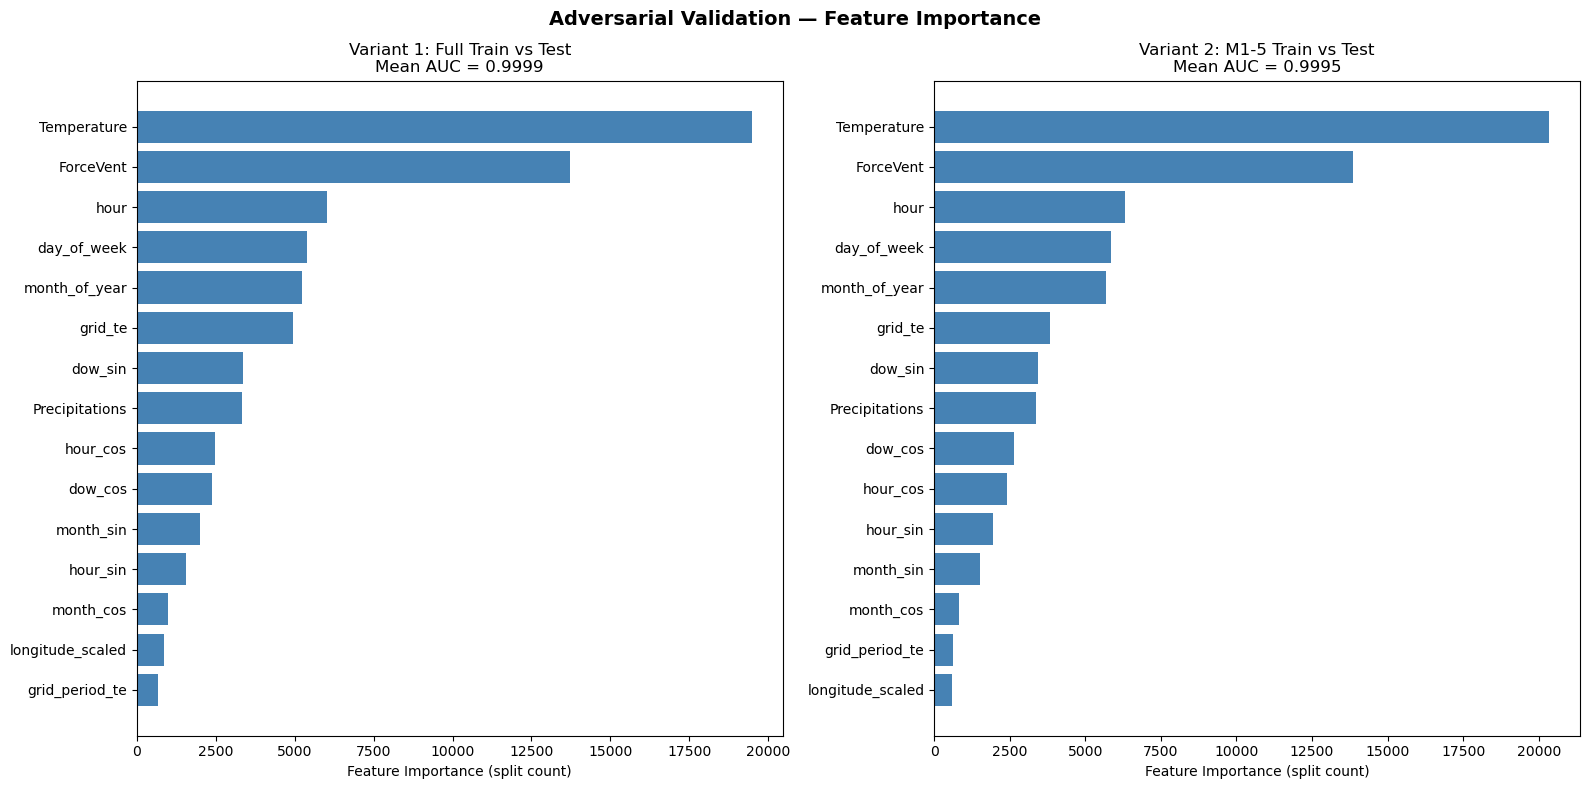

Saved: figures/av_feature_importance.png


In [12]:
# ── AV Feature Importance (both variants) ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, imp, title, auc_val in [
    (axes[0], av1_importances, 'Variant 1: Full Train vs Test', av1_mean_auc),
    (axes[1], av2_importances, 'Variant 2: M1-5 Train vs Test', av2_mean_auc),
]:
    sorted_idx = np.argsort(imp)[::-1][:15]
    ax.barh(range(len(sorted_idx)), imp[sorted_idx][::-1], color='steelblue')
    ax.set_yticks(range(len(sorted_idx)))
    ax.set_yticklabels([AV_FEATURES[i] for i in sorted_idx][::-1])
    ax.set_xlabel('Feature Importance (split count)')
    ax.set_title(f'{title}\nMean AUC = {auc_val:.4f}')

fig.suptitle('Adversarial Validation — Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/av_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/av_feature_importance.png')

Computing AV probabilities for all train samples...
  AV probability stats for train samples:
    Mean: 0.1058
    Std:  0.1914
    Min:  0.0000  Max: 0.9951
    Median: 0.0100

  AV probability by month (mean):
    Month  1: 0.1857  (n=505,486)
    Month  2: 0.1874  (n=478,240)
    Month  3: 0.2041  (n=517,284)
    Month  4: 0.1121  (n=519,078)
    Month  5: 0.0024  (n=450,341)
    Month  6: 0.0022  (n=484,050)
    Month  7: 0.0018  (n=529,927)
    Month  8: 0.0175  (n=531,972)
    Month  9: 0.1093  (n=514,097)
    Month 10: 0.0513  (n=538,948)
    Month 11: 0.1975  (n=437,770)
    Month 12: 0.1985  (n=569,353)


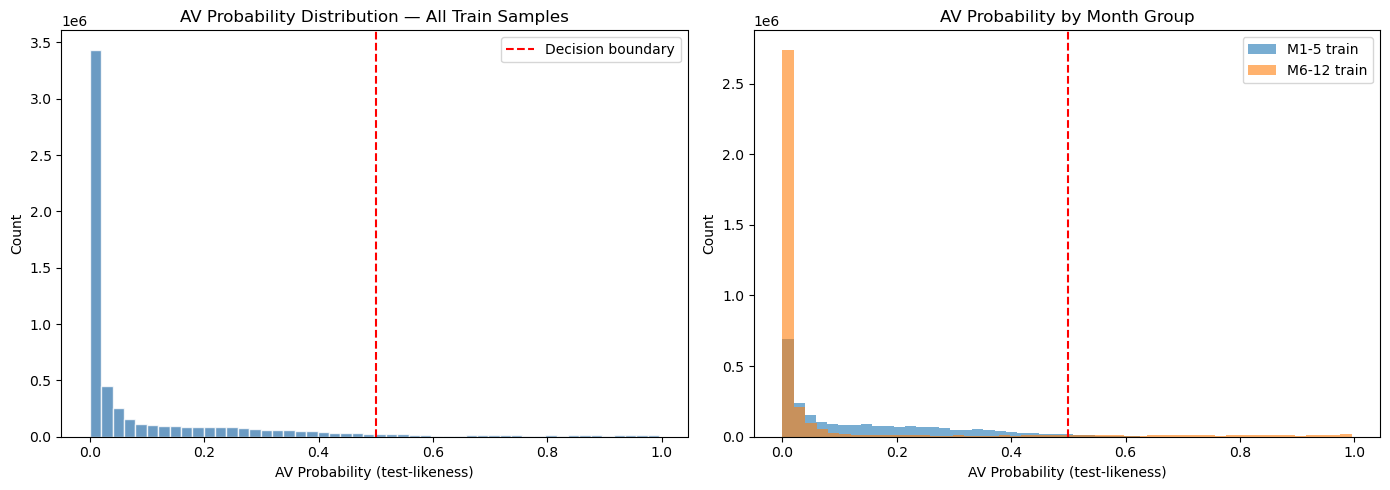

Saved: figures/av_probability_distribution.png


In [13]:
# ── Compute AV probabilities for ALL train samples (for sample weighting) ────
# Use M1-5 variant (Variant 2) — more relevant since test is M1-5 only.
# Re-train on full combined data with 5-fold to get OOF probs for train samples.

# For the FULL training set: train a final AV model on the combined M1-5 data
# and predict probability for every train row
print('Computing AV probabilities for all train samples...')

# Train final AV model on the M1-5 combined data
av_final = lgb.LGBMClassifier(**av_params)
av_final.fit(X_av2, y_av2)

# Predict "test-likeness" for ALL train rows
av_probs_train = av_final.predict_proba(train_df[AV_FEATURES])[:, 1]

print(f'  AV probability stats for train samples:')
print(f'    Mean: {av_probs_train.mean():.4f}')
print(f'    Std:  {av_probs_train.std():.4f}')
print(f'    Min:  {av_probs_train.min():.4f}  Max: {av_probs_train.max():.4f}')
print(f'    Median: {np.median(av_probs_train):.4f}')

# Distribution by month
print(f'\n  AV probability by month (mean):')
for m in range(1, 13):
    mask = train_df['month_of_year'].values == m
    if mask.sum() > 0:
        print(f'    Month {m:2d}: {av_probs_train[mask].mean():.4f}  (n={mask.sum():,})')

# Histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(av_probs_train, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0.5, color='red', ls='--', label='Decision boundary')
axes[0].set_xlabel('AV Probability (test-likeness)')
axes[0].set_ylabel('Count')
axes[0].set_title('AV Probability Distribution — All Train Samples')
axes[0].legend()

# By M1-5 vs M6-12
axes[1].hist(av_probs_train[m15_mask], bins=50, alpha=0.6, label='M1-5 train', color='tab:blue')
axes[1].hist(av_probs_train[~m15_mask], bins=50, alpha=0.6, label='M6-12 train', color='tab:orange')
axes[1].axvline(0.5, color='red', ls='--')
axes[1].set_xlabel('AV Probability (test-likeness)')
axes[1].set_ylabel('Count')
axes[1].set_title('AV Probability by Month Group')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/av_probability_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/av_probability_distribution.png')

### Part 2 — Temporal CV (Diagnostic)

Train LGB + XGB on months 1-4 (using v7 params), validate on month 5.
This simulates the actual test scenario more closely than random 5-fold CV.

Compare:
- **Random 5-fold OOF**: v7 baseline (0.6429 ensemble, 0.6515 M1-5)
- **Temporal CV**: train M1-4, predict M5 → expected to be lower, quantifies the "temporal gap"

In [15]:
# ── Part 2: Temporal CV — Train M1-4, Validate M5 ────────────────────────────
import xgboost as xgb_lib
import time

EXCLUDE_COLS = ['invalid_ratio', 'grid_lon', 'grid_lat', 'grid_id', 'grid_period']
FEATURES = [c for c in train_df.columns if c not in EXCLUDE_COLS]

# Split by month
m14_mask = train_df['month_of_year'].isin([1,2,3,4]).values
m5_mask  = train_df['month_of_year'].values == 5

X_train_temporal = train_df.loc[m14_mask, FEATURES]
y_train_temporal = y[m14_mask]
X_val_temporal   = train_df.loc[m5_mask, FEATURES]
y_val_temporal   = y[m5_mask]

# Sample weights (log1p of total_count, same as v7)
w_train_temporal = np.log1p(train_df.loc[m14_mask, 'total_count'].values)

print(f'Temporal CV split:')
print(f'  Train (M1-4): {X_train_temporal.shape[0]:,} rows')
print(f'  Valid (M5):    {X_val_temporal.shape[0]:,} rows')
print(f'  Train fraction: {X_train_temporal.shape[0] / len(train_df):.1%}')

# ── LGB Temporal ─────────────────────────────────────────────────────────────
lgb_params_temporal = {
    'num_leaves':        100,
    'learning_rate':     0.0564,
    'min_child_samples': 69,
    'reg_lambda':        0.452,
    'reg_alpha':         1.243,
    'feature_fraction':  0.844,
    'bagging_fraction':  0.972,
    'objective':         'regression',
    'metric':            'l2',
    'boosting_type':     'gbdt',
    'bagging_freq':      5,
    'verbose':           -1,
    'n_jobs':            -1,
    'random_state':      SEED,
    'n_estimators':      10000,
}

print(f'\nTraining LGB (temporal: M1-4 → M5)...')
t0 = time.time()
lgb_temporal = lgb.LGBMRegressor(**lgb_params_temporal)
lgb_temporal.fit(
    X_train_temporal, y_train_temporal,
    eval_set=[(X_val_temporal, y_val_temporal)],
    sample_weight=w_train_temporal,
    callbacks=[
        lgb.early_stopping(stopping_rounds=150, verbose=False),
        lgb.log_evaluation(period=2000),
    ]
)
lgb_temporal_pred = lgb_temporal.predict(X_val_temporal)
lgb_temporal_rho  = spearmanr(y_val_temporal, lgb_temporal_pred)[0]
lgb_temporal_time = time.time() - t0
print(f'  LGB Temporal: Spearman = {lgb_temporal_rho:.4f}  (best_iter={lgb_temporal.best_iteration_})  [{lgb_temporal_time:.0f}s]')

# ── XGB Temporal ─────────────────────────────────────────────────────────────
xgb_params_temporal = {
    'max_depth':         10,
    'learning_rate':     0.0362,
    'min_child_weight':  11,
    'reg_lambda':        1.561,
    'reg_alpha':         1.239,
    'colsample_bytree':  0.951,
    'subsample':         0.948,
    'objective':         'reg:squarederror',
    'eval_metric':       'rmse',
    'tree_method':       'hist',
    'n_estimators':      10000,
    'verbosity':         0,
    'random_state':      SEED,
    'n_jobs':            -1,
    'early_stopping_rounds': 150,
}

print(f'\nTraining XGB (temporal: M1-4 → M5)...')
t0 = time.time()
xgb_temporal = xgb_lib.XGBRegressor(**xgb_params_temporal)
xgb_temporal.fit(
    X_train_temporal, y_train_temporal,
    eval_set=[(X_val_temporal, y_val_temporal)],
    sample_weight=w_train_temporal,
    verbose=2000,
)
xgb_temporal_pred = xgb_temporal.predict(X_val_temporal)
xgb_temporal_rho  = spearmanr(y_val_temporal, xgb_temporal_pred)[0]
xgb_temporal_time = time.time() - t0
print(f'  XGB Temporal: Spearman = {xgb_temporal_rho:.4f}  (best_iter={xgb_temporal.best_iteration})  [{xgb_temporal_time:.0f}s]')

# ── Temporal Ensemble ────────────────────────────────────────────────────────
# Search optimal weights for temporal predictions
best_temporal_rho = -1
best_temporal_w   = None
for lgb_w in np.arange(0, 1.01, 0.05):
    xgb_w = 1.0 - lgb_w
    pred = lgb_w * lgb_temporal_pred + xgb_w * xgb_temporal_pred
    rho = spearmanr(y_val_temporal, pred)[0]
    if rho > best_temporal_rho:
        best_temporal_rho = rho
        best_temporal_w = (lgb_w, xgb_w)

print(f'\n  Temporal Ensemble: Spearman = {best_temporal_rho:.4f}  weights=LGB={best_temporal_w[0]:.2f}, XGB={best_temporal_w[1]:.2f}')

print(f'\n=== Temporal CV vs Random CV Comparison ===')
print(f'  {"Metric":<30} {"Random 5-Fold (v7)":<20} {"Temporal (M1-4→M5)":<20} {"Delta":<10}')
print(f'  {"-"*80}')
print(f'  {"LGB Spearman":<30} {"0.6336":<20} {lgb_temporal_rho:<20.4f} {lgb_temporal_rho - 0.6336:<+10.4f}')
print(f'  {"XGB Spearman":<30} {"0.6403":<20} {xgb_temporal_rho:<20.4f} {xgb_temporal_rho - 0.6403:<+10.4f}')
print(f'  {"Ensemble Spearman":<30} {"0.6429":<20} {best_temporal_rho:<20.4f} {best_temporal_rho - 0.6429:<+10.4f}')
print(f'  {"v7 M1-5 OOF (ref)":<30} {"0.6515":<20} {"—":<20}')
print(f'  {"Platform (v7, ref)":<30} {"0.5636":<20} {"—":<20}')

Temporal CV split:
  Train (M1-4): 2,020,088 rows
  Valid (M5):    450,341 rows
  Train fraction: 33.2%

Training LGB (temporal: M1-4 → M5)...
[2000]	valid_0's l2: 0.0836861
[4000]	valid_0's l2: 0.0823174
  LGB Temporal: Spearman = 0.5972  (best_iter=5660)  [192s]

Training XGB (temporal: M1-4 → M5)...
[0]	validation_0-rmse:0.36144
[2000]	validation_0-rmse:0.28683
[2747]	validation_0-rmse:0.28661
  XGB Temporal: Spearman = 0.5970  (best_iter=2597)  [119s]

  Temporal Ensemble: Spearman = 0.6017  weights=LGB=0.50, XGB=0.50

=== Temporal CV vs Random CV Comparison ===
  Metric                         Random 5-Fold (v7)   Temporal (M1-4→M5)   Delta     
  --------------------------------------------------------------------------------
  LGB Spearman                   0.6336               0.5972               -0.0364   
  XGB Spearman                   0.6403               0.5970               -0.0433   
  Ensemble Spearman              0.6429               0.6017               -0.0412   


### Part 2b — Temporal CV with AV Weights

If adversarial validation found significant shift (AUC > 0.6), we test whether
using AV probabilities as additional sample weights improves temporal CV performance.

`final_weight = log1p(total_count) * av_probability`

This gives higher weight to training samples that "look like" test data.

In [16]:
# ── Part 2b: Temporal CV with AV-weighted samples ────────────────────────────
# Only run if AV found meaningful shift
av_actionable = max(av1_mean_auc, av2_mean_auc) > 0.55  # lower threshold for diagnostic
print(f'AV actionable (AUC > 0.55): {av_actionable}  (best AUC: {max(av1_mean_auc, av2_mean_auc):.4f})')

if av_actionable:
    # Combined weight: log1p(total_count) * av_probability
    av_combined_weight = np.log1p(train_df['total_count'].values) * av_probs_train
    w_train_av = av_combined_weight[m14_mask]

    print(f'\nAV-combined weight stats (M1-4 train):')
    print(f'  Original log1p weight: mean={w_train_temporal.mean():.3f}, std={w_train_temporal.std():.3f}')
    print(f'  AV-combined weight:    mean={w_train_av.mean():.3f}, std={w_train_av.std():.3f}')

    # ── LGB with AV weights ──────────────────────────────────────────────────
    print(f'\nTraining LGB (temporal + AV weights)...')
    t0 = time.time()
    lgb_av = lgb.LGBMRegressor(**lgb_params_temporal)
    lgb_av.fit(
        X_train_temporal, y_train_temporal,
        eval_set=[(X_val_temporal, y_val_temporal)],
        sample_weight=w_train_av,
        callbacks=[
            lgb.early_stopping(stopping_rounds=150, verbose=False),
            lgb.log_evaluation(period=2000),
        ]
    )
    lgb_av_pred = lgb_av.predict(X_val_temporal)
    lgb_av_rho  = spearmanr(y_val_temporal, lgb_av_pred)[0]
    print(f'  LGB + AV weights: Spearman = {lgb_av_rho:.4f}  (best_iter={lgb_av.best_iteration_})  [{time.time()-t0:.0f}s]')

    # ── XGB with AV weights ──────────────────────────────────────────────────
    print(f'\nTraining XGB (temporal + AV weights)...')
    t0 = time.time()
    xgb_av = xgb_lib.XGBRegressor(**xgb_params_temporal)
    xgb_av.fit(
        X_train_temporal, y_train_temporal,
        eval_set=[(X_val_temporal, y_val_temporal)],
        sample_weight=w_train_av,
        verbose=2000,
    )
    xgb_av_pred = xgb_av.predict(X_val_temporal)
    xgb_av_rho  = spearmanr(y_val_temporal, xgb_av_pred)[0]
    print(f'  XGB + AV weights: Spearman = {xgb_av_rho:.4f}  (best_iter={xgb_av.best_iteration})  [{time.time()-t0:.0f}s]')

    # ── AV Ensemble ──────────────────────────────────────────────────────────
    best_av_ens_rho = -1
    best_av_ens_w = None
    for lgb_w in np.arange(0, 1.01, 0.05):
        xgb_w = 1.0 - lgb_w
        pred = lgb_w * lgb_av_pred + xgb_w * xgb_av_pred
        rho = spearmanr(y_val_temporal, pred)[0]
        if rho > best_av_ens_rho:
            best_av_ens_rho = rho
            best_av_ens_w = (lgb_w, xgb_w)

    print(f'\n  AV Ensemble: Spearman = {best_av_ens_rho:.4f}  weights=LGB={best_av_ens_w[0]:.2f}, XGB={best_av_ens_w[1]:.2f}')

    print(f'\n=== AV Weights Effect (Temporal CV on M5) ===')
    print(f'  {"Model":<25} {"No AV weight":<15} {"+ AV weight":<15} {"Delta":<10}')
    print(f'  {"-"*65}')
    print(f'  {"LGB":<25} {lgb_temporal_rho:<15.4f} {lgb_av_rho:<15.4f} {lgb_av_rho - lgb_temporal_rho:<+10.4f}')
    print(f'  {"XGB":<25} {xgb_temporal_rho:<15.4f} {xgb_av_rho:<15.4f} {xgb_av_rho - xgb_temporal_rho:<+10.4f}')
    print(f'  {"Ensemble":<25} {best_temporal_rho:<15.4f} {best_av_ens_rho:<15.4f} {best_av_ens_rho - best_temporal_rho:<+10.4f}')

    av_weights_helpful = best_av_ens_rho > best_temporal_rho + 0.001
    print(f'\n  AV weights helpful (delta > +0.001): {av_weights_helpful}')
    if av_weights_helpful:
        print('  → Recommend using AV-weighted training for full 5-fold retrain')
        np.save(f'{MODEL_DIR}av_probs_train.npy', av_probs_train)
        print(f'  → Saved av_probs_train.npy for use in full retraining')
    else:
        print('  → AV weights did not improve temporal CV — skip for production')
else:
    print('AV shift too weak — skipping AV-weighted temporal CV.')
    lgb_av_rho = None
    xgb_av_rho = None
    best_av_ens_rho = None

AV actionable (AUC > 0.55): True  (best AUC: 0.9999)

AV-combined weight stats (M1-4 train):
  Original log1p weight: mean=1.780, std=0.929
  AV-combined weight:    mean=0.304, std=0.328

Training LGB (temporal + AV weights)...
[2000]	valid_0's l2: 0.0847692
[4000]	valid_0's l2: 0.0837149
[6000]	valid_0's l2: 0.0832975
  LGB + AV weights: Spearman = 0.5902  (best_iter=6856)  [259s]

Training XGB (temporal + AV weights)...
[0]	validation_0-rmse:0.36113
[2000]	validation_0-rmse:0.28941
[3260]	validation_0-rmse:0.28875
  XGB + AV weights: Spearman = 0.5896  (best_iter=3110)  [166s]

  AV Ensemble: Spearman = 0.5937  weights=LGB=0.50, XGB=0.50

=== AV Weights Effect (Temporal CV on M5) ===
  Model                     No AV weight    + AV weight     Delta     
  -----------------------------------------------------------------
  LGB                       0.5972          0.5902          -0.0070   
  XGB                       0.5970          0.5896          -0.0074   
  Ensemble              

In [17]:
# ── Section D Summary ─────────────────────────────────────────────────────────
print('=' * 70)
print('SECTION D SUMMARY — Adversarial Validation + Temporal CV')
print('=' * 70)

print(f'\n--- Part 1: Adversarial Validation ---')
print(f'  AUC (Full train vs test):   {av1_mean_auc:.4f}')
print(f'  AUC (M1-5 train vs test):   {av2_mean_auc:.4f}')
if av1_mean_auc > 0.6:
    print(f'  → Significant distribution shift detected')
elif av1_mean_auc > 0.55:
    print(f'  → Moderate distribution shift detected')
else:
    print(f'  → Train and test distributions are similar (AUC near 0.5)')

print(f'\n--- Part 2: Temporal CV (M1-4 → M5) ---')
print(f'  LGB Temporal Spearman:      {lgb_temporal_rho:.4f}  (v7 random CV: 0.6336, delta: {lgb_temporal_rho - 0.6336:+.4f})')
print(f'  XGB Temporal Spearman:      {xgb_temporal_rho:.4f}  (v7 random CV: 0.6403, delta: {xgb_temporal_rho - 0.6403:+.4f})')
print(f'  Ensemble Temporal Spearman: {best_temporal_rho:.4f}  (v7 random CV: 0.6429, delta: {best_temporal_rho - 0.6429:+.4f})')

if best_av_ens_rho is not None:
    print(f'\n--- Part 2b: AV-Weighted Temporal CV ---')
    print(f'  Ensemble + AV weights:      {best_av_ens_rho:.4f}  (vs no-AV: {best_temporal_rho:.4f}, delta: {best_av_ens_rho - best_temporal_rho:+.4f})')

print(f'\n--- Conclusions ---')
temporal_gap = 0.6429 - best_temporal_rho
print(f'  Temporal CV gap from random CV: {temporal_gap:.4f}')
print(f'  Platform gap (v7):              {0.6429 - 0.5636:.4f}')
if temporal_gap > 0.02:
    print(f'  → Temporal CV confirms significant temporal distribution shift')
    print(f'  → Temporal CV Spearman ({best_temporal_rho:.4f}) is a better proxy for platform score than random CV')
else:
    print(f'  → Temporal gap is small — random CV is a reasonable proxy')

if best_av_ens_rho is not None and best_av_ens_rho > best_temporal_rho + 0.001:
    print(f'  → AV weights IMPROVE temporal CV — recommend for full retraining')
else:
    print(f'  → AV weights did NOT improve temporal CV — not recommended for production')

print(f'\n--- Next Steps ---')
print(f'  Use Temporal CV as primary evaluation metric for subsequent experiments')
print(f'  Baseline to beat (Temporal Ensemble): {best_temporal_rho:.4f}')
print('=' * 70)

SECTION D SUMMARY — Adversarial Validation + Temporal CV

--- Part 1: Adversarial Validation ---
  AUC (Full train vs test):   0.9999
  AUC (M1-5 train vs test):   0.9995
  → Significant distribution shift detected

--- Part 2: Temporal CV (M1-4 → M5) ---
  LGB Temporal Spearman:      0.5972  (v7 random CV: 0.6336, delta: -0.0364)
  XGB Temporal Spearman:      0.5970  (v7 random CV: 0.6403, delta: -0.0433)
  Ensemble Temporal Spearman: 0.6017  (v7 random CV: 0.6429, delta: -0.0412)

--- Part 2b: AV-Weighted Temporal CV ---
  Ensemble + AV weights:      0.5937  (vs no-AV: 0.6017, delta: -0.0080)

--- Conclusions ---
  Temporal CV gap from random CV: 0.0412
  Platform gap (v7):              0.0793
  → Temporal CV confirms significant temporal distribution shift
  → Temporal CV Spearman (0.6017) is a better proxy for platform score than random CV
  → AV weights did NOT improve temporal CV — not recommended for production

--- Next Steps ---
  Use Temporal CV as primary evaluation metric f